In [1]:
%load_ext autoreload
%autoreload 2

# --- Standard Library ---
import copy
import pickle
import os
from copy import deepcopy
from itertools import combinations
from multiprocessing import Pool, cpu_count

# --- Scientific / Numerical ---
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import norm

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown, Math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm
import corner
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

# --- Astropy ---
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
from astropy.table import Table
from astropy.units import Quantity

# --- SLSim ---
import slsim.Deflectors as deflectors
import slsim.Pipelines as pipelines
import slsim.Sources as sources
from slsim.Lenses.lens import Lens
from slsim.Lenses.lens_pop import LensPop
from slsim.LOS.los_pop import LOSPop
from slsim.Plots.lens_plots import LensingPlots

# --- Lenstronomy / HierArc ---
import emcee
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.lens_model import LensModel
from hierarc.Sampling.ParamManager.cosmo_param import CosmoParam
from hierarc.Sampling.mcmc_sampling import MCMCSampler

# --- ChainConsumer ---
from chainconsumer import Chain, ChainConfig, ChainConsumer, PlotConfig, Truth
from chainconsumer.plotting import plot_contour

# --- Local Utilities ---
# from pdspl_analysis_utils import normalize_data, get_pairs_table_PDSPL, kdtree_matching_n_dim, draw_lens_from_given_zs

import numpy as np
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from astropy.cosmology import Flatw0waCDM
from dspl_inference import run_dspl_inference, draw_lens_from_given_zs

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/paras/sharmapyenv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# load the pdspl_samples object with pickle
with open('../../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

## Generate PDSPL kwargs_likelihoods

In [ ]:
# --- 1. CONFIGURATION ---

# Truth (The Universe we want to recover)
truth = {
    'h0': 70.0,
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 
    'gamma_sigma': 0.16
}

# Fixed parameters (H0 is fixed)
fixed_params = {'h0': 70.0, 
'lambda_sigma': 0.05, 
    'gamma_sigma': 0.16
}

# Initial Guess for walkers
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 
    'gamma_pl': 2.0,}

# Priors
my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    # 'om': ('gaussian', 0.3, 0.05),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    # 'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    # 'gamma_sigma': ('uniform', 0.0, 0.5)
}

# Initial Scatter for walkers
my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1,
    'gamma_pl': 0.1,
}

scenarios_to_plot = [
                    'DSPL',
                    # 'lsst_4most_spec-z_sigma_v',
                    # 'lsst_4most_spec-z', 
                    'lsst_y1', 
                    'lsst_y10', 
                    ]

# Define the 5 Forecast Scenarios
scenarios = {
}

# add PDSPL samples
for key in pdspl_samples.keys():
    if key not in scenarios:
        scenarios[key] = {
            'name': f"PDSPL ({pdspl_samples[key]['name']})",
            'down_sampling': 10,
            'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
            'color': pdspl_samples[key]['color'],
            'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
            'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
            'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        }

# --- 2. EXECUTION LOOP ---

cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# We need the labels from the first run to set up the plot later
param_labels = None 

print(f"{'SCENARIO':<30} | {'N_LENS':<10} | {'SIGMA':<10} | {'STATUS'}")
print("-" * 75)

for key in scenarios_to_plot:
    if key == 'DSPL':
        continue
    sc = scenarios[key]
    name = sc['name']

    pairs_table = sc['pairs_table']
    # based on scatter vs dissimilarity fit, get the scatter in beta_E to use for this sample
    coeffs = sc['coeffs']
    num_samples = sc['num_lenses'] // sc['down_sampling']
    
    kwargs_pseudo_dspl_list = []
    for i in range(num_samples):
        # pick random pair
        rand_index = np.random.choice(len(pairs_table))
        z_lens = pairs_table["z_D"][rand_index]
        z1 = pairs_table["z_S1"][rand_index]
        z2 = pairs_table["z_S2"][rand_index]

        dissimilarity = pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors']['dissimilarity'][rand_index]
        rel_scatter_in_beta_E = np.polyval(coeffs, dissimilarity)

        # add los and measurement noise
        sigma_beta_meas = 0.01  # relative uncertainty on the measured Einstein radius due to measurement errors
        sigma_beta_los = 0.01  # relative uncertainty on the measured Einstein radius due to line-of-sight structures
        
        rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)

        kwargs_pseudo_dspl_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_rel=rel_scatter_in_beta_E, 
            down_sampling=sc['down_sampling'], 
            with_noise=False, # <-- SET TO FALSE FOR A PURE UNBIASED FORECAST
            cosmo=cosmo_true))
        
    # B. Run Inference
    # Note: We reduce steps slightly for the massive dataset to save time, 
    # but 1000 is generally fine thanks to vectorization.
    samples, labels = run_dspl_inference(
        kwargs_pseudo_dspl_list,
        n_walkers=64,
        n_steps=1000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling']
    )
    
    sc['samples'] = samples
    param_labels = labels # Save labels for plotting
    print(f"{name:<30} | {num_samples:<10} | {sc['sigma_beta']:<10} | DONE")

SCENARIO                       | N_LENS     | SIGMA      | STATUS
---------------------------------------------------------------------------
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'lambda_sigma', 'gamma_sigma']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl']
Down Sampling : 10


100%|██████████| 1000/1000 [06:53<00:00,  2.42it/s]


PDSPL (LSST Y1)                | 2875       | 0.1943744260825557 | DONE
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'lambda_sigma', 'gamma_sigma']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl']
Down Sampling : 10


100%|██████████| 1000/1000 [17:43<00:00,  1.06s/it]

PDSPL (LSST Y10)               | 8593       | 0.1906916663370256 | DONE


In [8]:
scenarios['DSPL'] = {
        'name': 'DSPL (500 lenses)',
        'down_sampling': 1, # Use all lenses without down-sampling
        'num_lenses': 500,
        'color': '#1f77b4',
        'sigma_beta': 0.00
    } 


print(f"{'SCENARIO':<30} | {'N_LENS':<10} | {'SIGMA':<10} | {'STATUS'}")
print("-" * 75)

for key in ['DSPL']:
    sc = scenarios[key]
    name = sc['name']
    num_samples = sc['num_lenses'] // sc['down_sampling']
    
    kwargs_dspl_list = []
    for i in range(num_samples):
        
        z_lens = np.random.normal(loc=0.5, scale=0.1)  # Random lens redshift around 0.5
        z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)  # Random source 1 redshift greater than lens redshift
        z2 = np.random.uniform(low=z1 + 0.1, high=3.0)  # Random source 2 redshift greater than source 1 redshift

        rel_scatter_in_beta_E = sc['sigma_beta']  # Use the predefined scatter for the DSPL scenario

        # add los and measurement noise
        sigma_beta_meas = 0.01  # relative uncertainty on the measured Einstein radius due to measurement errors
        sigma_beta_los = 0.01  # relative uncertainty on the measured Einstein radius due to line-of-sight structures
        
        rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)

        kwargs_dspl_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_rel=rel_scatter_in_beta_E, 
            down_sampling=sc['down_sampling'], 
            with_noise=False, # <-- SET TO FALSE FOR A PURE UNBIASED FORECAST
            cosmo=cosmo_true))
        
    # B. Run Inference
    # Note: We reduce steps slightly for the massive dataset to save time, 
    # but 1000 is generally fine thanks to vectorization.
    samples, labels = run_dspl_inference(
        kwargs_dspl_list,
        n_walkers=64,
        n_steps=1000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling']
    )
    
    sc['samples'] = samples
    param_labels = labels # Save labels for plotting
    print(f"{name:<30} | {num_samples:<10} | {sc['sigma_beta']:<10} | DONE")

SCENARIO                       | N_LENS     | SIGMA      | STATUS
---------------------------------------------------------------------------
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'lambda_sigma', 'gamma_sigma']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl']
Down Sampling : 1


 41%|████      | 408/1000 [00:54<01:09,  8.56it/s]

100%|██████████| 1000/1000 [02:15<00:00,  7.38it/s]

DSPL (500 lenses)              | 500        | 0.0        | DONE



Generating Combined Plot...


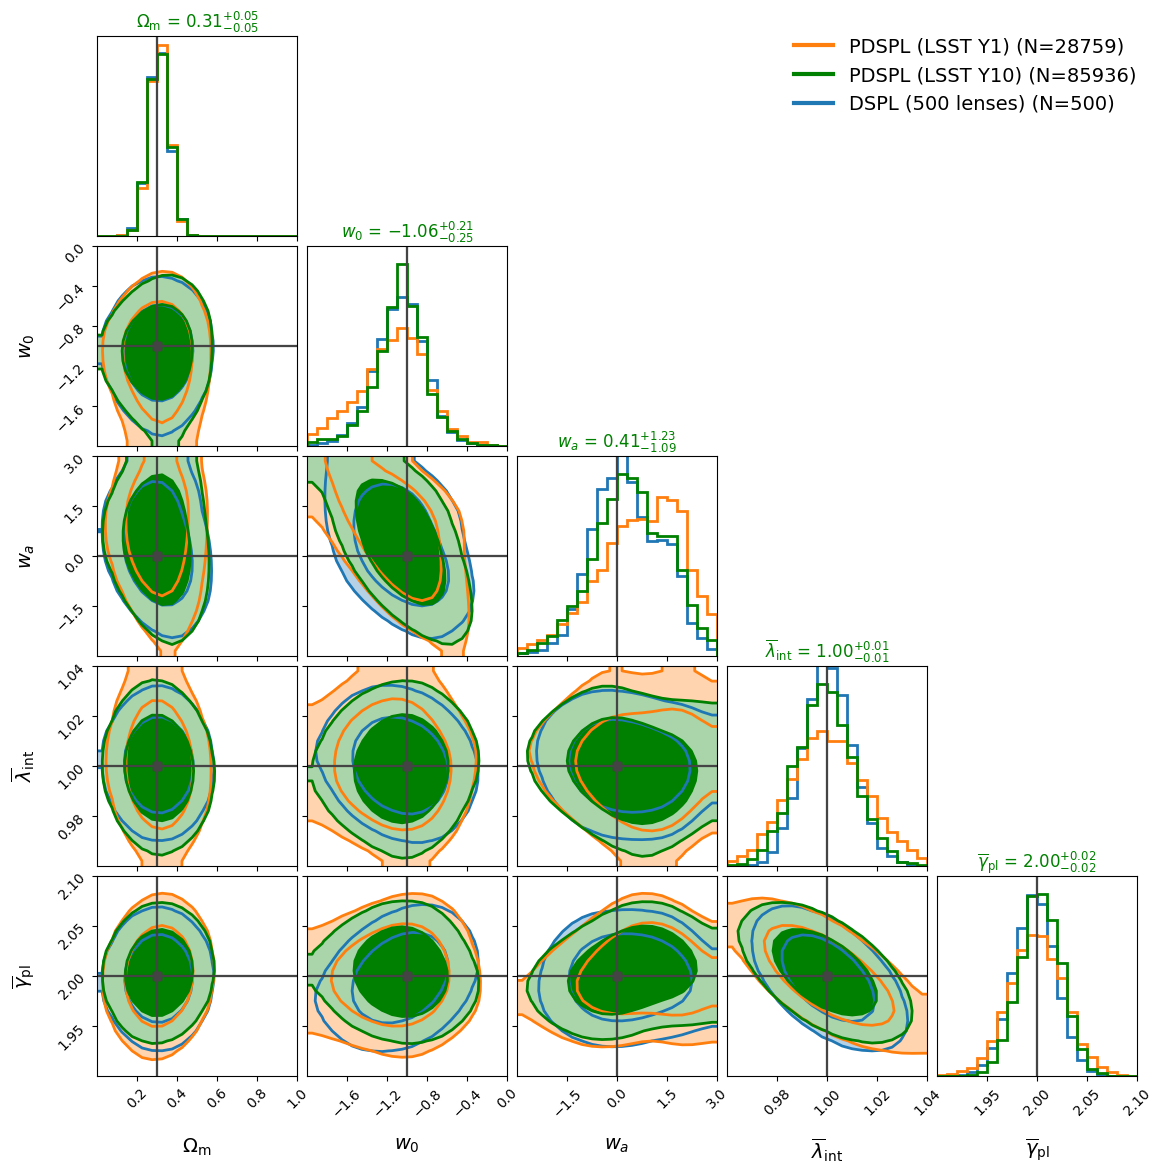

In [9]:
# --- 3. PLOTTING ---

print("\nGenerating Combined Plot...")

# 1. Sort scenarios to plot the largest (loosest) contours first
# This ensures tight contours are drawn ON TOP and aren't hidden.
# We use a heuristic: larger sigma / sqrt(N) -> looser constraint.
# (This is optional, but helps visibility)
# scenarios.sort(key=lambda x: x['sigma_beta'] / np.sqrt(x['num_lenses']), reverse=True)

# Determine sampled keys
sampled_keys = [k for k in truth.keys() if k not in fixed_params]
truth_values = [truth[k] for k in sampled_keys]

# Define nice looking labels
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 
    'w0': r"$w_0$", 
    'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma_{\gamma}$", 
    'lambda_sigma': r"$\sigma_{\lambda}$"
}
plot_labels = [latex_labels[k] for k in sampled_keys]

# Define Plot Ranges (Adjusted to fit all contours)
# You may need to tweak these slightly if your new chains drift
custom_ranges = [
    (0, 1),      # om
    (-2, 0),     # w0
    (-3, 3),      # wa
    (0.96, 1.04),     # lambda_int
    # (0.0, 0.10),      # lambda_sigma
    (1.9, 2.1),       # gamma_pl
    # (0.12, 0.20),     # gamma_sigma
]

# Create Figure
fig = None


# Loop to plot each scenario
for key in ['DSPL', 'lsst_y1', 'lsst_y10']:
    sc = scenarios[key]
    name = sc['name']
    color = sc['color']
    samples = sc['samples']
    
    # We use fill_contours=False to make them lines (easier to see overlap)
    # We use plot_density=False to avoid the messy grayscale background
    fig = corner.corner(
        samples,
        fig=fig,
        labels=plot_labels,
        # range=None, # Let corner decide ranges automatically for better fit
        range=custom_ranges, # Uncomment if you want strict ranges
        color=color,
        weights=np.ones(len(samples)) / len(samples),
        smooth=2,
        
        # CLEAN PLOT SETTINGS
        plot_datapoints=False,  # Hide the scatter points
        plot_density=False,     # Hide the grayscale map
        fill_contours=True,    # LINES ONLY (No fill)
        show_titles=True,      # Titles clutter the plot when overlapping
        
        # CONTOUR STYLE
        levels=[0.68, 0.95],    # 1 and 2 sigma
        hist_kwargs={"density": True, "linewidth": 2, "histtype": "step"},
        contour_kwargs={"linewidths": 2},
        
        # TRUTHS (Only draw once)
        truths=truth_values, # if i == 0 else None,
        truth_color="#444444",
        
        # FONT SIZES
        label_kwargs={"fontsize": 14},
        title_kwargs={"fontsize": 12, 'color': color}
    )

# --- 4. CUSTOM LEGEND ---
legend_handles = []
for key, sc in scenarios.items():
    if key not in scenarios_to_plot:
        continue
    # create a dummy line for the legend
    line = mlines.Line2D([], [], color=sc['color'], linewidth=3, 
                         label=f"{sc['name']} (N={sc['num_lenses']})")
    legend_handles.append(line)

# Place legend in the empty upper-right corner of the plot grid
# We grab the axes from the figure to position it relative to the subplot grid
axes = np.array(fig.axes).reshape((len(sampled_keys), len(sampled_keys)))

# Use the top-right-most subplot (which is usually hidden/empty in corner plots)
# as the anchor point.
legend_ax = axes[0, -1] 

# Add legend to the figure
fig.legend(
    handles=legend_handles,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Adjust x,y to move the box
    bbox_transform=fig.transFigure,
    fontsize=14,
    frameon=False
)

plt.show();